# Carbon Mapper products — reference walkthrough

How to get every Carbon Mapper product with `georeader`, in four short
sections: the **product registry**, **per-plume products** (L3A),
**scene tiles** (L2B), and **sources**. Ends with a cheat-sheet of what
is and isn't reachable on the current API.

Two facts shape everything (verified against the live API, 2026-07):

1. **STAC is history-only** — nothing after `v3a` (2025-12). All current
   data is served by the asset proxy, at URLs derived from each plume's
   own record. The reader does this for you; no version is hardcoded.
2. **Plumes are the only door to current data** — there is no way to
   browse recent tiles directly (`/catalog/scenes` is closed, STAC is
   stale). You discover a plume, then reach its products and its parent
   tile from there.


## Levels at a glance

| Level | Entity | What you get | Keyed by | Latest (2026+) | History (≤ 2025-12) |
|---|---|---|---|---|---|
| Plume record | plume | metadata + URL fields (`plume_tif` → L3A-vis, `con_tif` → L3A-ime) | `plume_id` | ✅ `/catalog/plumes/annotated` — **the only discovery route** | ✅ same |
| L3A vis + ime | image | per-plume crops: mask, concentrations, outlines, rgb, IME set | `plume_id` | ✅ asset proxy, URLs derived from the record | ✅ also in STAC (≤ v3a) |
| L2B + l2b-rgb | tile | full-swath cmf, uncertainty, artifact-mask, uas, rgb | scene name (from `plume_id`) | ✅ asset proxy — reachable **only via a plume**; no browsing (`/catalog/scenes` 401, STAC stale) | ✅ STAC (≤ v3a) |
| Sources (L4) | source | DBSCAN site clusters, stats, embedded plume records | `source_name` (re-clustered — never hardcode) | ✅ REST `/catalog/source*`, live | `l4a-*` STAC ≤ v3a, no per-item assets |
| L2C / L3C | detections / attribution | — | — | not exposed by the reader | — |

Publication timing: plume + L3A appear together (same-day to ~30-day
embargo observed); the L2B parent can lag by days-to-weeks and may sit
one version behind a re-versioned L3A.


## Setup

Auth resolves from `CARBONMAPPER_TOKEN`, `CARBONMAPPER_EMAIL`+`PASSWORD`,
or `~/.georeader/auth_carbonmapper.json`. The retry adapter and GDAL
settings keep the notebook polite under Carbon Mapper's rate limits.


In [1]:
import os

from georeader.readers.carbonmapper import (
    CarbonMapperConfig,
    CMCollectionSpec,
    CMPlumeImage,
    CMProductFamily,
    CMProductNotSelected,
    api_queries,
)
from georeader.readers.carbonmapper import products as P

# 429-resilient HTTP: Carbon Mapper rate-limits per account. Route every
# call in this kernel through a retry-aware session (honours Retry-After).
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

_session = requests.Session()
_session.mount("https://", HTTPAdapter(max_retries=Retry(
    total=8, backoff_factor=2.0,
    status_forcelist=(429, 500, 502, 503, 504),
    respect_retry_after_header=True,
    allowed_methods=frozenset(["GET", "POST"]),
)))
requests.get, requests.post, requests.request = (
    _session.get, _session.post, _session.request,
)

TOKEN = CarbonMapperConfig.load().refresh_access_token()

# Rasters stream over GDAL/libcurl — pass the token + retries there too.
os.environ["GDAL_HTTP_HEADERS"] = f"Authorization: Bearer {TOKEN}"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".tif,.TIF"
os.environ["GDAL_HTTP_MAX_RETRY"] = "5"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "3"

# Protagonist: the most recently published CH4 plume (preferring one
# with an emission estimate) — so every execution doubles as a live
# check that the newest data resolves every product. Re-runs pick
# whatever is newest at that moment.
latest = api_queries.list_plumes(TOKEN, gas="CH4", limit=5)
pick = next((p for p in latest if p.emission_auto is not None), latest[0])
PLUME_ID = pick.plume_id
print(f"plume_id = {PLUME_ID}  (newest of {len(latest)} fetched)")


plume_id = tan20260623t124240c80s4001-A  (newest of 5 fetched)


## 1 · The product registry

Every product is a descriptor in
`georeader.readers.carbonmapper.products`: its asset key, its
**family** (which collection serves it), and how it opens (raster →
`RasterioReader`, vector → shapely, text → `str`, quicklook → `bytes`).

Families and versioning: a `CMCollectionSpec` — the plume's
`(gas, cmf_type, version)` triple, parsed from its own record —
composes all four collection ids consistently.


In [2]:
# The registry is the single source of truth — print it rather than
# maintaining a parallel table by hand.
print(f"{'product':30s} {'family':8s} {'opens as':16s} description")
print("-" * 100)
for prod in P.ALL_PRODUCTS:
    kind = type(prod).__name__.removeprefix("CM").removesuffix("Product")
    print(f"{prod.key:30s} {prod.family.value:8s} {kind:16s} {prod.description}")

# One spec pins every collection id consistently (versions come from the
# plume record at run time — nothing here is hardcoded in the reader).
spec = CMCollectionSpec(version="v3d")
print()
for fam in CMProductFamily:
    print(f"{fam.name:8s} -> {spec.collection_id(fam)}")


product                        family   opens as         description
----------------------------------------------------------------------------------------------------
plume.tif                      l3a-vis  Raster           RGBA visualisation with plume overlay; band-4 alpha = plume mask
plume-concentrations.tif       l3a-vis  Raster           CH4 column density crop (ppm·m), thumbnail-grade (~41×48 px)
plume-outline.geojson          l3a-vis  Vector           Plume polygon (EPSG:4326) — the broader full-mask outline
rgb.tif                        l3a-vis  Raster           3-band uint8 true-colour crop of the plume window
ime-cmf-concentrations.tif     l3a-ime  Raster           IME-clipped CH4 column density (~11×11 px) — the emission_auto integrand (the record's con_tif field points here)
ime-cmf-mask.tif               l3a-ime  Raster           Binary mask of pixels contributing to emission_auto
ime-cmf-outline.geojson        l3a-ime  Vector           IME-significance polygon (tight

## 2 · Straight off the record — URLs only, no reader, no API

Pretend all you have is the record itself (the JSON item, or a
CSV-export row — same content, flat). This section uses **nothing but
`json` + `requests`**: the products below are exactly what the
record's five URL fields provide, in full — two georeferenced rasters
and three quicklook PNGs. The links are signed CDN URLs, so they
download **without any token** (and expire — persist files, not URLs).

Everything else in the registry — the geo `rgb.tif`,
`plume-concentrations.tif`, both outlines, `ime-cmf-mask.tif`, the
L2B tile — is **not reachable from the record's URLs**. That gap is
what the reader API closes, starting in §3.


In [3]:
import json
from pathlib import Path

# Pretend all you have is the exported JSON record. Save it once, then
# use ONLY the file — no reader classes, no typed API from here to the
# end of this section. (A CSV-export row is the same thing, flat.)
RECORD_FILE = Path("/tmp/cm_notebooks") / f"{PLUME_ID}.json"
RECORD_FILE.parent.mkdir(parents=True, exist_ok=True)
if not RECORD_FILE.exists():
    r = requests.get(
        f"https://api.carbonmapper.org/api/v1/catalog/plume/{PLUME_ID}",
        headers={"Authorization": f"Bearer {TOKEN}"}, timeout=60,
    )
    r.raise_for_status()
    RECORD_FILE.write_bytes(r.content)

record = json.loads(RECORD_FILE.read_text())   # <- the only input now

URL_FIELDS = ["plume_tif", "con_tif", "plume_png", "rgb_png", "plume_rgb_png"]
print(f"{'field':14s} {'set?':4s} filename at the other end")
print("-" * 72)
for f in URL_FIELDS:
    url = record.get(f) or ""
    tail = url.split("?")[0].rsplit("/", 1)[-1] if url else ""
    print(f"{f:14s} {'yes' if url else '—':4s} {tail}")


field          set? filename at the other end
------------------------------------------------------------------------
plume_tif      yes  tan20260623t124240c80s4001-A_l3a-vis-ch4-mfa-v3d_plume.tif
con_tif        yes  tan20260623t124240c80s4001-A_l3a-ime-ch4-mfa-v3d_ime-cmf-concentrations.tif
plume_png      yes  tan20260623t124240c80s4001-A_l3a-vis-ch4-mfa-v3d_plume.png
rgb_png        yes  tan20260623t124240c80s4001-A_l3a-vis-ch4-mfa-v3d_rgb.png
plume_rgb_png  yes  tan20260623t124240c80s4001-A_l3a-vis-ch4-mfa-v3d_plume-rgb.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer
from shapely.ops import transform as shp_transform


def plot_outline(ax, geom_4326, dst_crs):
    """Reproject the plume outline into dst_crs and stroke it in red."""
    if geom_4326 is None:
        return
    tr = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    g = shp_transform(tr.transform, geom_4326)
    polys = list(g.geoms) if g.geom_type == "MultiPolygon" else [g]
    for p in polys:
        x, y = p.exterior.xy
        ax.plot(x, y, color="red", lw=1.4, solid_capstyle="round")


def to_display(reader, rgb=False):
    """Load a reader -> (array, extent, crs) ready for imshow."""
    geo = reader.load()
    arr = np.asarray(geo.values)
    b = geo.bounds
    extent = (b[0], b[2], b[1], b[3])
    if rgb:
        im = np.moveaxis(arr[:3], 0, -1).astype("float32")
        lo, hi = np.nanpercentile(im, [2, 98])
        return np.clip((im - lo) / max(hi - lo, 1e-9), 0, 1), extent, str(geo.crs)
    a = arr.squeeze().astype("float32")
    nd = reader.nodata
    if nd is not None:
        a = np.where(a == nd, np.nan, a)
    return a, extent, str(geo.crs)


plume_tif      -> plume.tif                           12 KB
con_tif        -> ime-cmf-concentrations.tif          42 KB
plume_png      -> plume.png                            8 KB


rgb_png        -> rgb.png                             37 KB


plume_rgb_png  -> plume-rgb.png                       49 KB


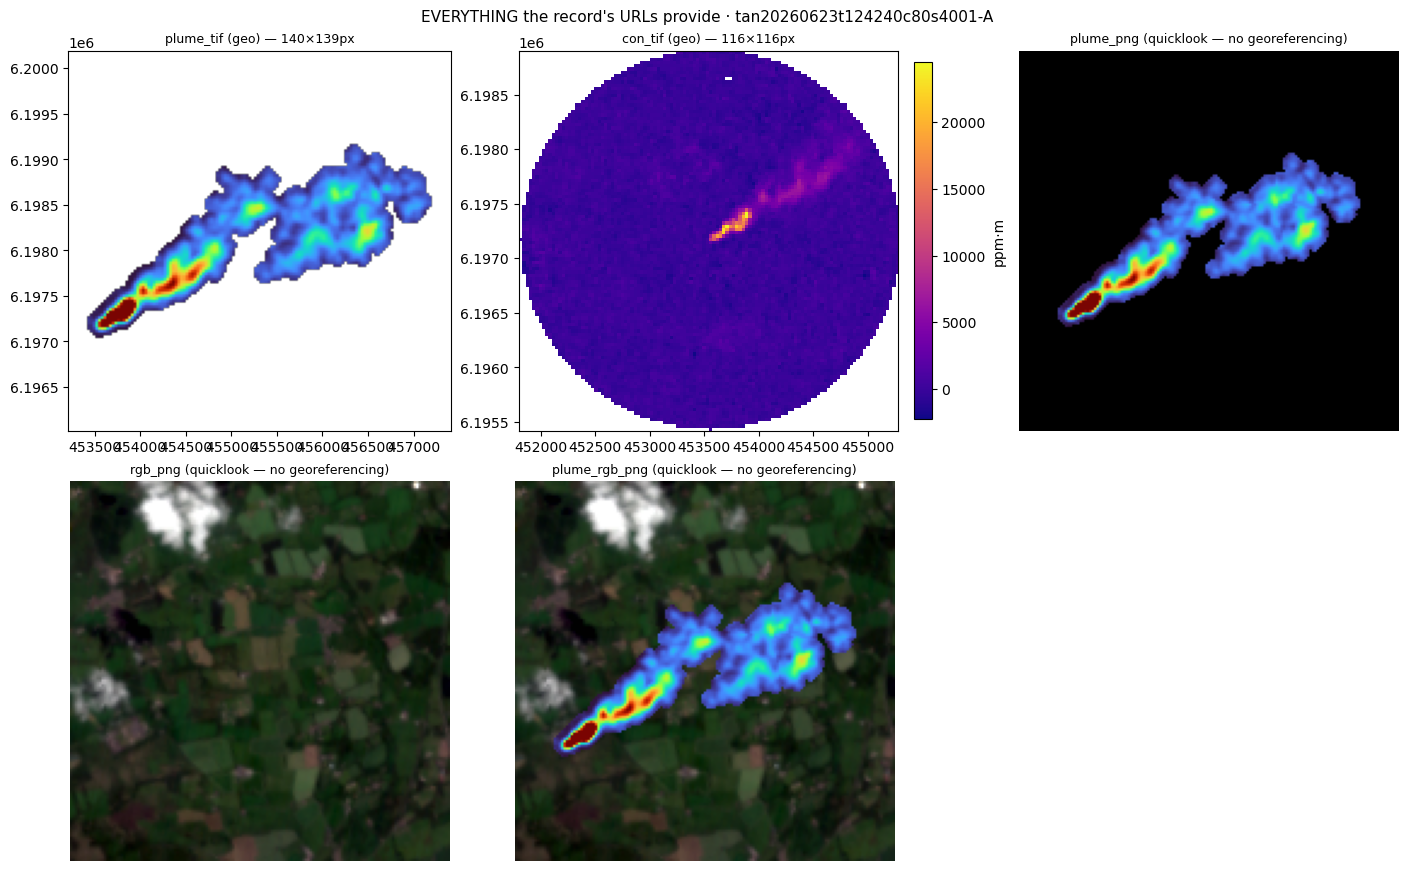

In [5]:
# Download every URL the record carries — with NO token: the public
# record's links are signed CDN URLs that work as-is (and expire,
# which is why you persist the files, not the links).
import rasterio

DROP = Path("/tmp/cm_notebooks") / f"record_{PLUME_ID}"
DROP.mkdir(parents=True, exist_ok=True)

files = {}
for field in URL_FIELDS:
    url = record.get(field)
    if not url:
        continue
    dest = DROP / url.split("?")[0].rsplit("/", 1)[-1].split("_")[-1]
    if not dest.exists():
        rr = requests.get(url, timeout=120)   # <- no Authorization header
        rr.raise_for_status()
        dest.write_bytes(rr.content)
    files[field] = dest
    print(f"{field:14s} -> {dest.name:32s} {dest.stat().st_size // 1024:>5d} KB")

fig, axes = plt.subplots(2, 3, figsize=(14, 8.6), constrained_layout=True)
axes = axes.ravel()
axes[-1].set_axis_off()
for ax, (field, path) in zip(axes, files.items()):
    if path.suffix == ".tif":
        with rasterio.open(path) as ds:
            arr, b, nd = ds.read(), ds.bounds, ds.nodata
        if arr.shape[0] >= 3:
            ax.imshow(np.moveaxis(arr, 0, -1),
                      extent=(b.left, b.right, b.bottom, b.top), origin="upper")
        else:
            a = arr.squeeze().astype("float32")
            if nd is not None:
                a = np.where(a == nd, np.nan, a)
            im = ax.imshow(a, extent=(b.left, b.right, b.bottom, b.top),
                           origin="upper", cmap="plasma")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ppm·m")
        ax.set_title(f"{field} (geo) — {arr.shape[-1]}×{arr.shape[-2]}px", fontsize=9)
        ax.set_aspect("equal")
    else:
        ax.imshow(plt.imread(path))
        ax.set_axis_off()
        ax.set_title(f"{field} (quicklook — no georeferencing)", fontsize=9)
fig.suptitle(
    f"EVERYTHING the record's URLs provide · {PLUME_ID}", fontsize=11,
)
plt.show()


## 3 · Per-plume products via the API (L3A)

`CMPlumeImage` exposes the products **you select** as lazy properties
(`mask`, `concentrations`, `ime_concentrations`, `ime_mask`, `rgb`,
`outline`, `ime_outline`). Defaults = the 7 GeoTIFF/GeoJSON products;
PNG quicklooks are opt-in via `products=` and `img.product(...)`.

These are **thumbnail-grade** crops (11–100 px per side) — right for
previews and polygons, wrong for analysis. Analysis-grade comes from
the L2B parent in §3.


In [6]:
# NOW the reader API: the typed plume and the derived bundle. The
# default selection is the 7 GeoTIFF/GeoJSON products.
plume = api_queries.get_plume(TOKEN, PLUME_ID)
em = f"{plume.emission_auto:.0f} kg/h" if plume.emission_auto is not None else "no emission yet"
print(f"{plume.plume_id}  {em}  sector={plume.sector or '—'}")
print(f"collection_spec: {plume.collection_spec}")
print()

img = CMPlumeImage.from_cmrawplume(plume, token=TOKEN)
print(img)

# Selective bundle: ask for exactly what you need. Anything outside the
# selection raises CMProductNotSelected — no silent Nones.
lean = CMPlumeImage.from_cmrawplume(
    plume, token=TOKEN, products=(P.PLUME_OUTLINE, P.RGB_TIF),
)
print(f"\nlean bundle URLs: {sorted(lean.urls)}")
try:
    lean.concentrations
except CMProductNotSelected as exc:
    print(f"lean.concentrations -> CMProductNotSelected: {exc}")


tan20260623t124240c80s4001-A  11189 kg/h  sector=1B2
collection_spec: CMCollectionSpec(version='v3d', gas='ch4', cmf_type='mfa')

CMPlumeImage
  plume_id:       tan20260623t124240c80s4001-A
  assets present: ['plume.tif', 'plume-concentrations.tif', 'plume-outline.geojson', 'rgb.tif', 'ime-cmf-concentrations.tif', 'ime-cmf-mask.tif', 'ime-cmf-outline.geojson']
  spec:           CMCollectionSpec(version='v3d', gas='ch4', cmf_type='mfa')
  overview_level: full

lean bundle URLs: ['plume-outline.geojson', 'rgb.tif']
lean.concentrations -> CMProductNotSelected: "Product 'plume-concentrations.tif' (l3a-vis) was not selected on this bundle. Selected products: ['plume-outline.geojson', 'rgb.tif']. Pass it in `products=` at construction to use it."


In [7]:
def show(name, geom):
    if geom is None:
        print(f"{name:14s} (absent)")
    else:
        print(f"{name:14s} area={geom.area:.3e} deg^2  "
              f"bounds={tuple(round(b, 4) for b in geom.bounds)}")

show("outline", img.outline)          # broader plume polygon (canonical GeoJSON)
show("ime_outline", img.ime_outline)  # tighter — the emission_auto integration area


outline        area=4.386e-04 deg^2  bounds=(-3.7453, 55.9165, -3.685, 55.9359)


ime_outline    area=7.143e-05 deg^2  bounds=(-3.7434, 55.9173, -3.72, 55.9277)


### 3.1 Visualise

The three rasters worth a look, plume outline overlaid. Note the pixel
counts in the titles — this is why they're preview-grade.


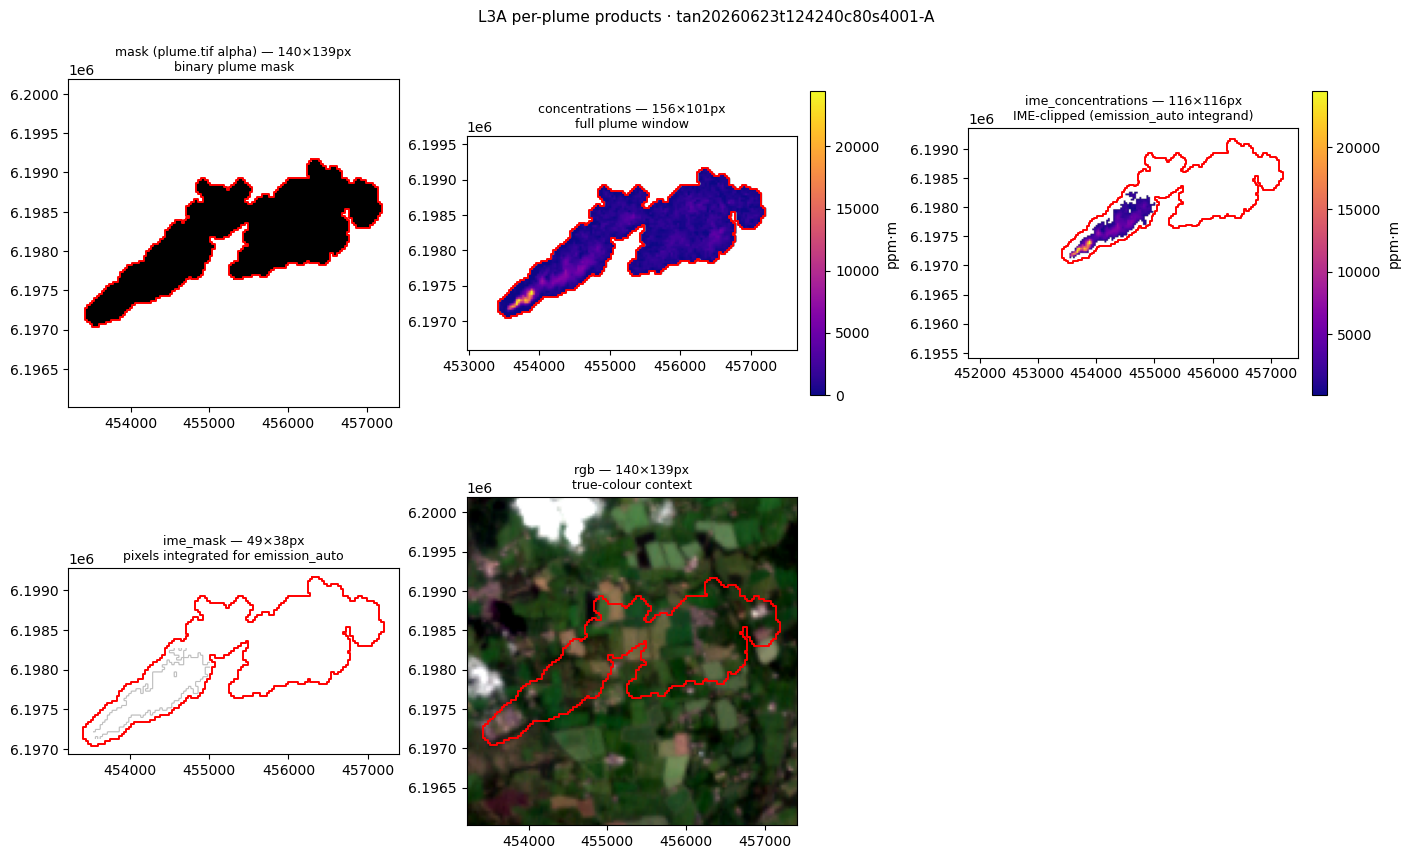

In [8]:
import time

# Every L3A raster, with the canonical outline overlaid. All of these
# are thumbnail-grade by design — analysis-grade rasters come from the
# L2B parent in the next section.
alpha = img.load_alpha_mask()   # plume.tif band-4 alpha -> boolean mask

panels = [
    ("mask (plume.tif alpha)", None, "Greys", "binary plume mask"),
    ("concentrations", img.concentrations, "plasma", "full plume window"),
    ("ime_concentrations", img.ime_concentrations, "plasma",
     "IME-clipped (emission_auto integrand)"),
    ("ime_mask", img.ime_mask, "Greys", "pixels integrated for emission_auto"),
    ("rgb", img.rgb, None, "true-colour context"),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8.6), constrained_layout=True)
axes = axes.ravel()
axes[-1].set_axis_off()

for ax, (name, reader, cmap, note) in zip(axes, panels):
    if name.startswith("mask"):
        if alpha is None:
            ax.set_axis_off(); ax.set_title("mask (absent)"); continue
        b = alpha.bounds
        arr = np.asarray(alpha.values).squeeze()
        ax.imshow(arr, extent=(b[0], b[2], b[1], b[3]), origin="upper",
                  cmap="Greys", interpolation="nearest")
        crs = str(alpha.crs)
    elif reader is None:
        ax.set_axis_off(); ax.set_title(f"{name} (absent)"); continue
    else:
        time.sleep(1)  # be gentle with the asset gateway
        arr, extent, crs = to_display(reader, rgb=(cmap is None))
        if cmap is None:
            ax.imshow(arr, extent=extent, origin="upper")
        else:
            im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap)
            if "concentrations" in name:
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ppm·m")
    plot_outline(ax, img.outline, crs)
    h, w = arr.shape[:2]
    ax.set_title(f"{name} — {w}×{h}px\n{note}", fontsize=9)
    ax.set_aspect("equal")
fig.suptitle(f"L3A per-plume products · {PLUME_ID}", fontsize=11)
plt.show()


## 4 · Scene tiles (L2B)

The full-swath retrieval: `cmf`, `uncertainty` (+ unortho variants),
`artifact-mask`, `uas` sidecar, and the `rgb` sibling collection.
`img.tile` resolves it from the plume's spec — probing the plume's own
version first, older candidates as backup (L3A can be re-versioned
ahead of its L2B parent; this plume is exactly that case).


In [9]:
# One call resolves the L2B parent: the plume's own version is probed
# first, older candidates as backup (this plume is the re-versioned
# case: L3A=v3d, L2B still v3c). Lazy — nothing is read yet.
ir = img.tile
print(ir)
print(f"\nL2B collection: {str(ir.asset_paths['cmf']).split('/')[-6]}")


CMImageRaster
  scene_id:       tan20260623t124240c80s4001
  bands present:  ['cmf', 'cmf-unortho', 'uncertainty', 'uncertainty-unortho', 'artifact-mask', 'rgb']
  extra keys:     ['uas']
  overview_level: full

L2B collection: l2b-ch4-mfa-v3d


In [10]:
from pathlib import Path

# Cache the three bands we plot locally, so repeated reads don't hammer
# the gateway. Idempotent — re-runs use the files.
CACHE = Path("/tmp/cm_notebooks") / PLUME_ID
CACHE.mkdir(parents=True, exist_ok=True)
for band in ("cmf", "rgb", "uncertainty", "artifact-mask"):
    local = CACHE / f"{band}.tif"
    if not local.exists():
        r = requests.get(str(ir.asset_paths[band]),
                         headers={"Authorization": f"Bearer {TOKEN}"},
                         stream=True, timeout=120)
        if r.status_code == 404:
            # Optional asset — not every scene publishes every band
            # (e.g. artifact-mask is absent on some v3d scenes). Drop
            # the key so the reader's accessor returns None cleanly.
            ir.asset_paths.pop(band, None)
            print(f"{band:12s} not published for this scene (404)")
            continue
        r.raise_for_status()
        local.write_bytes(r.content)
    ir.asset_paths[band] = str(local)
    print(f"{band:12s} {local.stat().st_size // 1024:>6d} KB")


cmf            5475 KB
rgb            2582 KB
uncertainty    4702 KB
artifact-mask not published for this scene (404)


### 4.1 The full tile

The L2B assets are whole-swath rasters — identical to what the STAC
items served for ≤ v3a scenes. Only the L3A products are cropped.


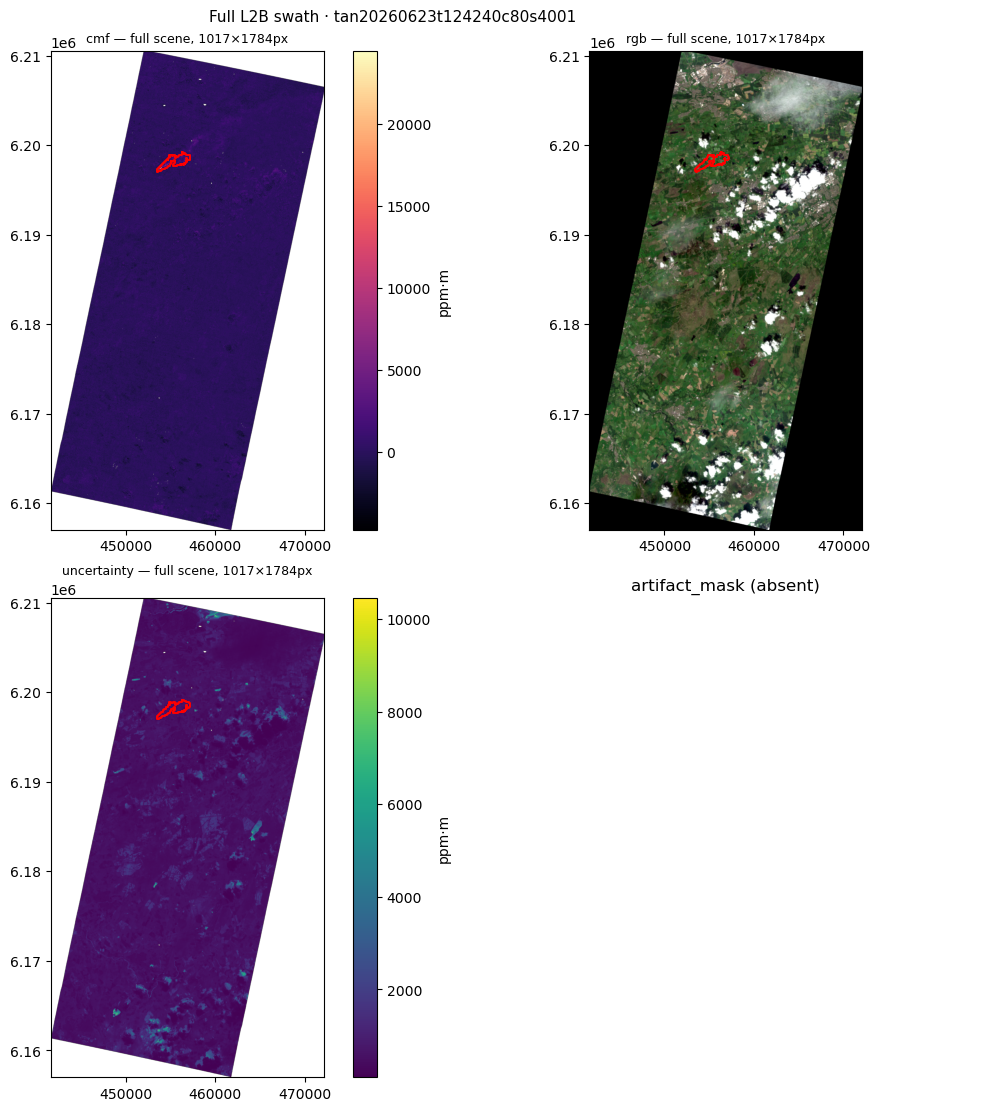

In [11]:
# The FULL scene — these are the same whole-swath GeoTIFFs the STAC
# items point at, not crops. The red outline marks where the plume
# sits in the swath (analysis-grade crops of it come next).
full_panels = [
    ("cmf", "magma", "ppm·m"),
    ("rgb", None, None),
    ("uncertainty", "viridis", "ppm·m"),
    ("artifact_mask", "Greys", None),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
for ax, (band, cmap, label) in zip(axes.ravel(), full_panels):
    reader = getattr(ir, band)
    if reader is None:
        ax.set_axis_off(); ax.set_title(f"{band} (absent)"); continue
    arr, extent, crs = to_display(reader, rgb=(cmap is None))
    if cmap is None:
        ax.imshow(arr, extent=extent, origin="upper")
    else:
        im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap)
        if label:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)
    plot_outline(ax, img.outline, crs)
    h, w = arr.shape[:2]
    ax.set_title(f"{band} — full scene, {w}×{h}px", fontsize=9)
    ax.set_aspect("equal")
fig.suptitle(f"Full L2B swath · {ir.scene_id}", fontsize=11)
plt.show()


### 4.2 Analysis-grade crops — the headline workflow

`tile_cmf` / `tile_rgb` / `tile_uncertainty` crop the L2B parent by the
plume outline at native resolution. This is the raster you quantify or
retrain on — not the L3A thumbnail.


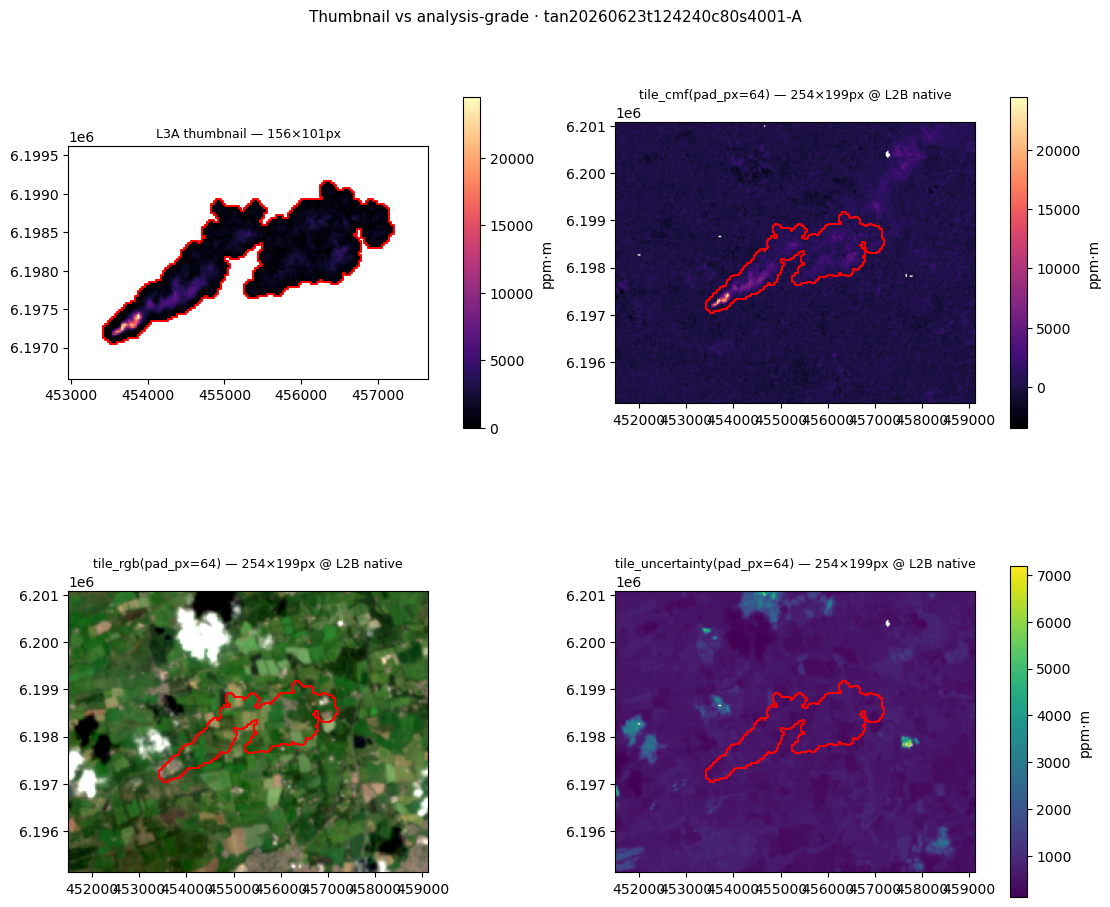

In [12]:
# The headline workflow: analysis-grade crops at L2B native resolution,
# next to the thumbnail-grade L3A product they replace.
crop_cmf = img.tile_cmf(pad_px=64)
crop_rgb = img.tile_rgb(pad_px=64)
crop_unc = img.tile_uncertainty(pad_px=64)

fig, axes = plt.subplots(2, 2, figsize=(11, 9.6), constrained_layout=True)
axes = axes.ravel()

arr, extent, crs = to_display(img.concentrations)
im = axes[0].imshow(arr, extent=extent, origin="upper", cmap="magma")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="ppm·m")
plot_outline(axes[0], img.outline, crs)
axes[0].set_title(f"L3A thumbnail — {arr.shape[1]}×{arr.shape[0]}px", fontsize=9)


def show_crop(ax, crop, title, cmap):
    a = np.asarray(crop.values)
    if cmap is None:
        im3 = np.moveaxis(a[:3], 0, -1).astype("float32")
        lo, hi = np.nanpercentile(im3, [2, 98])
        a = np.clip((im3 - lo) / max(hi - lo, 1e-9), 0, 1)
    else:
        a = np.where(a.squeeze() == -9999, np.nan, a.squeeze()).astype("float32")
    b = crop.bounds
    if cmap is None:
        ax.imshow(a, extent=(b[0], b[2], b[1], b[3]), origin="upper")
    else:
        im = ax.imshow(a, extent=(b[0], b[2], b[1], b[3]),
                       origin="upper", cmap=cmap)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ppm·m")
    plot_outline(ax, img.outline, str(crop.crs))
    ax.set_title(f"{title} — {a.shape[1]}×{a.shape[0]}px @ L2B native", fontsize=9)


show_crop(axes[1], crop_cmf, "tile_cmf(pad_px=64)", "magma")
show_crop(axes[2], crop_rgb, "tile_rgb(pad_px=64)", None)
show_crop(axes[3], crop_unc, "tile_uncertainty(pad_px=64)", "viridis")
for ax in axes:
    ax.set_aspect("equal")
fig.suptitle(f"Thumbnail vs analysis-grade · {PLUME_ID}", fontsize=11)
plt.show()


## 5 · Sources

A source is Carbon Mapper's DBSCAN cluster of detections at one site.
The source detail embeds every attributed plume record, so per-site
stats need one call.


In [13]:
import pandas as pd

# Plume -> source (None if not yet DBSCAN-clustered), then per-source
# stats from the embedded plume records. Source names are re-clustered
# upstream — resolve them at run time, never hardcode.
src = api_queries.get_source_for_plume(TOKEN, PLUME_ID)
print(f"protagonist source: {src.source_name if src else '(not clustered yet)'}")

permian = api_queries.list_sources(
    TOKEN, bbox=(-104.5, 32.0, -103.5, 32.8), gas="CH4",
)
demo = max(permian, key=lambda s: s.plume_count or 0)
plumes = api_queries.list_plumes_for_source(TOKEN, demo.source_name)
em = pd.Series([p.emission_auto for p in plumes
                if p.emission_auto is not None])
pers = f"{demo.persistence:.2f}" if demo.persistence is not None else "—"
print(f"\n{demo.source_name}: {len(plumes)} detections, persistence={pers}")
print(f"emission kg/h: median={em.median():.0f}  p90={em.quantile(.9):.0f}  "
      f"max={em.max():.0f}")


protagonist source: CH4_1B2_100m_-3.74298_55.91781



CH4_1B2_250m_-104.11776_32.02621: 43 detections, persistence=0.75
emission kg/h: median=278  p90=866  max=1640


## Access cheat-sheet — what works where

Verified against the live API (2026-07):

| You want | Works | Route |
|---|---|---|
| Discover recent plumes | ✅ | `/catalog/plumes/annotated` (`api_queries.list_plumes`) |
| Latest L3A per-plume products (v3c/v3d) | ✅ | asset-proxy URLs derived from the plume record (`CMPlumeImage`) |
| Latest L2B tile for a known plume/scene | ✅ | asset proxy, plume's version probed first (`img.tile`, `get_image_raster_for_plume`) |
| Anything current via **STAC** | ❌ | registry stops at `-v3a` (items end 2025-12-16) — history only |
| Browse/list recent **tiles** without a plume | ❌ | `/catalog/scenes` 401s; STAC stale — plumes are the only door to current data |
| Plumes attributed to a source | ✅ | embedded records on `/catalog/source/{name}` (`list_plumes_for_source`) |

## See also

- [`api_explore.ipynb`](api_explore.ipynb) — the typed query layer (REST + STAC, filters, exceptions).
- [Carbon Mapper reader API reference](../modules/readers_module.md#carbon-mapper-reader).
